In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('pogo_meta_data.csv')

Paso 2.1 Efectuar preprocesamiento y limpieza de datos

In [6]:
# 1. REVISIÓN INICIAL
# ------------------------------------------------------
print("--- Dimensiones del Dataset (Filas, Columnas) ---")
print(df.shape)

print("\n--- Tipos de datos y Nulos ---")
df.info()

# 2. ELIMINACIÓN DE DUPLICADOS
# ------------------------------------------------------
duplicados = df.duplicated().sum()
print(f"\n--- Filas duplicadas detectadas: {duplicados} ---")

if duplicados > 0:
    df.drop_duplicates(inplace=True)
    print('Duplicados eliminados')
else:
    print('No hay duplicados')

# 3. STANDARIZACIÓN DE NOMBRES DE COLUMNAS
# ------------------------------------------------------

df.columns = df.columns.str.lower().str.replace(' ', '_')
print('\n--- Nombres de columnas normalizados ---')
print(df.columns.tolist())

# 4. DETECCIÓN DE NULOS (MISSING VALUES)
# ------------------------------------------------------
print('\n --- Cantidad de nulos por columna ---')
nulos = df.isnull().sum()
print(nulos[nulos > 0]) # Solo las columnas que tienen problemas

--- Dimensiones del Dataset (Filas, Columnas) ---
(679, 24)

--- Tipos de datos y Nulos ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 679 entries, 0 to 678
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Pokemon         679 non-null    object 
 1   Score           679 non-null    float64
 2   Type 1          679 non-null    object 
 3   Type 2          679 non-null    object 
 4   Attack          679 non-null    float64
 5   Defense         679 non-null    float64
 6   Stamina         679 non-null    int64  
 7   Stat Product    679 non-null    int64  
 8   Level           679 non-null    float64
 9   Fast Move       679 non-null    object 
 10  Charged Move 1  679 non-null    object 
 11  Charged Move 2  679 non-null    object 
 12  Damage_CM_1     679 non-null    int64  
 13  Energy_CM_1     679 non-null    int64  
 14  DPE_CM_1        679 non-null    float64
 15  Damage_CM_2     679 non-null    i

Paso 2.2 Realizar un analisis descriptivo. Explicar en que consiste la dataset,
que significa cada columna, realizar estadísticas básicas (ver clase 32),
identifica outliers.

In [7]:
# 1. Estadísticas de las columnas numéricas (Promedio, Mínimo, Máximo...)
print('--- Estadisticas Numericas ---')
display(df.describe())

# 2. Estadísticas de las columnas de texto (Conteo, valor más frecuente...)
print('\n --- Estadisticas Categoricas (Texto)')
display(df.describe(include='object'))

# 3. Revisión rápida de lo que podría ser un "falso" nulo
# A veces, si un Pokemon no tiene segundo tipo, en lugar de ser nulo pone "None" como texto.
print('\n --- Valores unicos en type_2 (Primeros 10) ---')
print(df['type_2'].unique()[:10])

--- Estadisticas Numericas ---


,score,attack,defense,stamina,stat_product,level,damage_cm_1,energy_cm_1,dpe_cm_1,damage_cm_2,energy_cm_2,dpe_cm_2,damage_fm,turns_fm,energy_fm,cd_fm,dpt_fm,ept_fm
count,648.000000,648.000000,648.000000,648.000000,6.480000e+02,648.000000,648.000000,648.000000,648.000000,648.000000,648.000000,648.000000,648.000000,648.000000,648.000000,648.000000,648.000000,648.000000
mean,71.149074,123.337191,113.261728,129.145062,1.736756e+06,27.769290,74.976852,-45.532407,1.630046,84.706790,-53.541667,1.554306,6.793210,1.331790,8.001543,1.165123,2.873256,3.431867
std,11.430811,16.403761,23.735508,27.861225,2.395813e+05,8.772036,23.092605,8.657248,0.317962,28.813323,11.319231,0.308752,3.841587,0.877034,3.343544,0.436602,0.972722,0.726579
min,21.800000,59.300000,63.200000,85.000000,1.251209e+06,12.000000,20.000000,-80.000000,0.400000,10.000000,-80.000000,0.140000,0.000000,0.000000,2.000000,0.500000,0.000000,2.000000
25%,64.300000,113.575000,98.000000,115.000000,1.591912e+06,20.500000,55.000000,-50.000000,1.430000,65.000000,-60.000000,1.375000,4.000000,1.000000,6.000000,1.000000,2.000000,3.000000
50%,71.550000,123.400000,110.100000,126.000000,1.724806e+06,25.500000,70.000000,-45.000000,1.640000,90.000000,-55.000000,1.640000,6.000000,1.000000,8.000000,1.000000,3.000000,3.500000
75%,80.025000,135.000000,122.925000,137.000000,1.884568e+06,37.500000,90.000000,-40.000000,1.800000,100.000000,-45.000000,1.785000,9.000000,2.000000,10.000000,1.500000,3.670000,4.000000
max,95.800000,167.900000,244.500000,396.000000,2.739618e+06,50.000000,150.000000,-35.000000,2.380000,170.000000,-35.000000,2.360000,16.000000,4.000000,20.000000,2.500000,5.330000,5.000000



 --- Estadisticas Categoricas (Texto)


,pokemon,type_1,type_2,fast_move,charged_move_1,charged_move_2
count,648,648,648,648,648,648
unique,648,18,19,63,97,116
top,Cranidos,water,none,Confusion,Body Slam,Psychic
freq,1,89,306,41,36,27



 --- Valores unicos en type_2 (Primeros 10) ---
['psychic' 'none' 'fairy' 'steel' 'flying' 'ghost' 'ground' 'fighting'
 'dragon' 'ice']


Identificar outliers

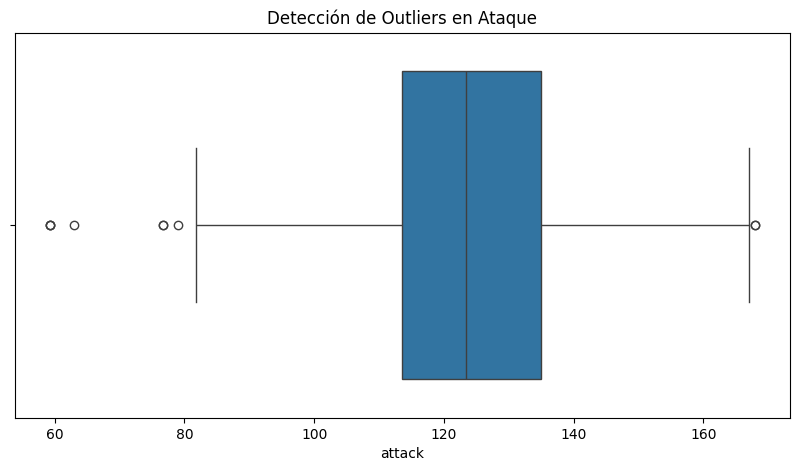

In [8]:
# 1. Gráfico para ver los "Outliers" visualmente
# plt.figure(figsize=(10, 5)):
# Prepara un lienzo en blanco.
# figsize=(10, 5) dimensiones: 10 pulgadas de ancho por 5 de alto. 
plt.figure(figsize=(10, 5))

# sns.boxplot(x=df['attack']):
# boxplot: es el tipo de gráfico: Diagrama de Caja.
# x=df['attack']: dibujar la distribución de la columna attack en el eje horizontal (x)
sns.boxplot(x=df['attack'])
plt.title('Detección de Outliers en Ataque')
plt.show()



Caza de outliers

In [ ]:
# df.sort_values(by='attack', ascending=False):
    # sort_values: ordenar los valores
    # by='attack': Úsalos según su ataque.
    # ascending=False: Esto es clave. Si fuera True (verdadero), 
    # pondría a los más débiles primero (ascendente: 1, 2, 3...). 
    # Al poner False, ordenamos de mayor a menor".

# .head(10):
#     Como el dataset tiene cientos de filas, .head(10) 
#     Solo la cabeza (el principio) de la lista, dame los primeros 10

top_attackers = df.sort_values(by='attack', ascending=False).head(10)
print(top_attackers)

               pokemon  score   type_1  type_2  attack  defense  stamina  \
469           Sharpedo   66.5    water    dark   167.9     64.1      123   
405  Sharpedo (Shadow)   68.9    water    dark   167.9     64.1      123   
666   Kadabra (Shadow)   46.7  psychic    none   167.1     89.4       90   
653            Kadabra   49.5  psychic    none   167.1     89.4       90   
566          Rampardos   60.3     rock    none   166.0     66.2      123   
678           Cranidos   21.8     rock    none   165.3     63.2      129   
156            Haunter   80.7    ghost  poison   163.3     87.0       96   
497           Archeops   65.1     rock  flying   162.8     80.3      105   
486             Archen   65.4     rock  flying   162.1     73.6      116   
563              Absol   60.4     dark    none   158.6     82.4      108   

     stat_product  level    fast_move  ... dpe_cm_1 damage_cm_2  energy_cm_2  \
469       1324956   24.5    Waterfall  ...     1.56          40          -35   
405

El Método Matemático (Rango Intercuartílico) Q3 + 1.5 * IQR
Usamos una fórmula estándar. Vamos a calcular el límite exacto.


In [11]:
# 1. Calculamos los Cuartiles (Q1 es el 25% y Q3 es el 75%)
Q1 = df['attack'].quantile(0.25)
Q3 = df['attack'].quantile(0.75)
IQR = Q3 - Q1 # Rango Intercuartílico (La "caja" del medio)

# 2. Definimos la frontera (La fórmula estándar es Q3 + 1.5 veces el rango)
limite_superior = Q3 + 1.5 * IQR

print(f"Límite para ser outlier: {limite_superior:.2f}")

# 3. Filtramos: ¿Quiénes superan esa frontera?
outliers_reales = df[df['attack'] > limite_superior]
print(f"Cantidad de outliers encontrados: {len(outliers_reales)}")
display(outliers_reales[['pokemon', 'attack', 'type_1']].sort_values(by='attack', ascending=False))

Límite para ser outlier: 167.14
Cantidad de outliers encontrados: 2


,pokemon,attack,type_1
405,Sharpedo (Shadow),167.9,water
469,Sharpedo,167.9,water


Paso 2.3 Identificar Insights o datos de valor.


Vamos a buscar dos insights clave:

El "Meta" de los Tipos: ¿Qué tipo elemental (Fuego, Agua, Dragón...) es el más fuerte en promedio?

El dilema del "Glass Cannon" (Cañón de cristal): ¿Es verdad que los Pokémon que pegan mucho tienen muy poca defensa?

--- Ranking de Tipos por Ataque Promedio (Top 5) ---
type_1
steel     116.530435
fairy     118.183333
ground    118.375000
water     118.858427
poison    119.690625
Name: attack, dtype: float64


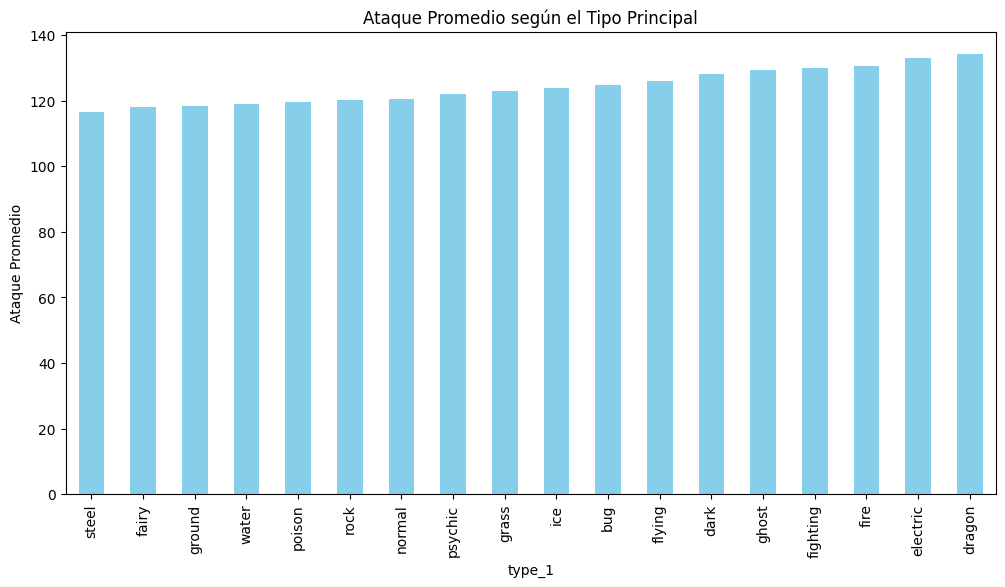

In [14]:
# INSIGHT 1: ¿Cuál es el tipo más fuerte en promedio?
# ---------------------------------------------------
# Agrupamos por 'type_1', calculamos el promedio de ataque y ordenamos

top_types = df.groupby('type_1')['attack'].mean().sort_values(ascending=True)

print("--- Ranking de Tipos por Ataque Promedio (Top 5) ---")
print(top_types.head(5))

# (Formato del grafico)
plt.figure(figsize=(12, 6))
top_types.plot(kind='bar', color='skyblue')
plt.title('Ataque Promedio según el Tipo Principal')
plt.ylabel('Ataque Promedio')
plt.show()

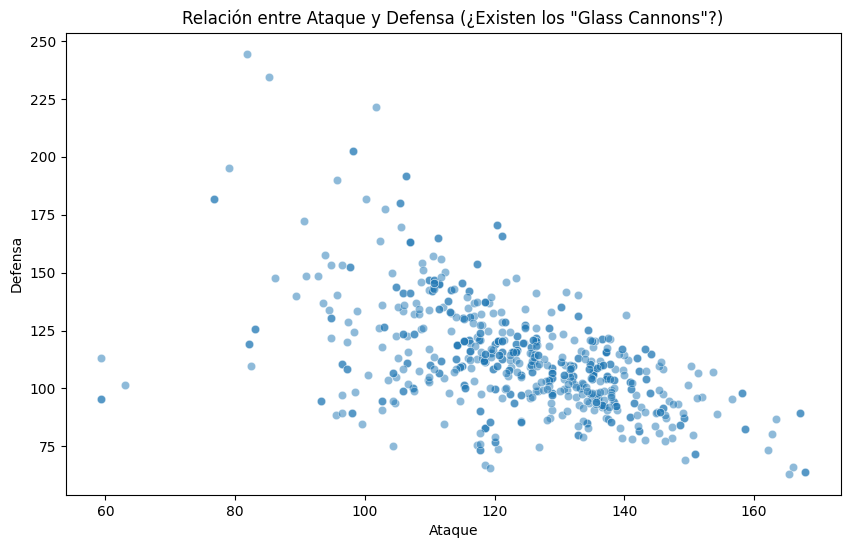

Correlación matemática entre Ataque y Defensa: -0.53


In [16]:
# INSIGHT 2: Correlación Ataque vs Defensa
# ---------------------------------------------------
# Usamos un Scatter Plot (gráfico de dispersión) para ver la relación
# alpha=0.5: Esto el grafico hace semitransparente. Para ver si hay puntos uno encima de otro

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='attack', y='defense', alpha=0.5)
plt.title('Relación entre Ataque y Defensa (¿Existen los "Glass Cannons"?)')
plt.xlabel('Ataque')
plt.ylabel('Defensa')
plt.show()

# Calculamos el número exacto de la correlación
# 1 = Van de la mano | -1 = Son opuestos | 0 = No tienen nada que ver
correlacion = df['attack'].corr(df['defense'])
print(f"Correlación matemática entre Ataque y Defensa: {correlacion:.2f}")

¡El gráfico y el número cuentan una historia muy interesante sobre el equilibrio del juego! Vamos a interpretar las dos pistas que tenemos aquí: el gráfico de dispersión y el número de correlación (-0.53).

El Signo Negativo (-): El valor es -0.53. En estadística, un signo menos significa una relación inversa.

Cuando una variable sube (Ataque), la otra tiende a bajar (Defensa).

Visualmente, esto se ve en la "nube" de puntos que va descendiendo de izquierda a derecha.

La Fuerza del Número (0.53): La correlación se mide de 0 a 1. Un 0.53 es una correlación moderada.

No es una regla perfecta (no es -1.0), lo que significa que hay excepciones, pero la tendencia es clara.

En resumen: El juego está diseñado para que los Pokémon no sean perfectos. Si quieres uno que pegue muy fuerte (Ataque alto en el eje X), probablemente tendrás que sacrificar su resistencia (Defensa baja en el eje Y).

Paso 2.4: Construir KPIs

Vamos a crear un KPI de "Resistencia Real" (o Bulk).

    La Defensa reduce el daño.

    La Stamina (Salud) es cuánta vida tiene.

In [20]:
# 1. Crear el KPI 'bulk' (Defensa * Aguante)
df['bulk'] = df['defense'] * df['stamina']

# 2. Ordenar para ver el top 5 de los mas resistentes
top_tanks = df.sort_values(by='bulk', ascending=False).head(5)

print("--- Top 5 Tanques Definitivos ---")
display(top_tanks[['pokemon', 'bulk', 'defense', 'stamina', 'type_1']])

--- Top 5 Tanques Definitivos ---


,pokemon,bulk,defense,stamina,type_1
334,Chansey,44748.0,113.0,396,normal
9,Wobbuffet (XL),33866.1,101.7,333,psychic
13,Bastiodon (XL),33496.5,244.5,137,rock
506,Blissey,33079.9,109.9,301,normal
35,Bastiodon,30954.0,234.5,132,rock


Paso 2.5: Feature Engineering "A priori"

In [26]:
# 1. CREAR NUEVA CARACTERÍSTICA (Feature Creation)
# Vamos a crear una columna simple para saber si el Pokémon tiene doble tipo o es puro.
# Esto nos servirá luego para ver si los "híbridos" son mejores.
df['is_dual_type'] = df['type_2'] != 'None'.lower()

# 2. DETECTAR COLUMNAS IRRELEVANTES (Feature Selection)
# Buscamos columnas que tengan UN SOLO valor en todas las filas (no sirven para comparar).
columnas_constantes = [col for col in df.columns if df[col].nunique() <= 1]

print("--- Nueva columna creada: 'is_dual_type' ---")
display(df[['pokemon', 'type_1', 'type_2', 'is_dual_type']].head())

print(f"\n--- Columnas sospechosas de ser irrelevantes (solo 1 valor único) ---")
if len(columnas_constantes) > 0:
    print(f"Se encontraron: {columnas_constantes}")
    # Si quisiesemos borrar las columnas sospechosas descomentar la linea de abajo
    # df.drop(columns=columnas_constantes, inplace=True)
else:
    print("¡Todas las columnas tienen variedad de datos! No hay nada obvio para borrar.")

--- Nueva columna creada: 'is_dual_type' ---


,pokemon,type_1,type_2,is_dual_type
0,Medicham (XL),fighting,psychic,True
1,Deoxys (Defense),psychic,none,False
2,Azumarill (XL),water,fairy,True
3,Stunfisk (Galarian),ground,steel,True
4,Altaria,dragon,flying,True



--- Columnas sospechosas de ser irrelevantes (solo 1 valor único) ---
¡Todas las columnas tienen variedad de datos! No hay nada obvio para borrar.


In [27]:
# Guardamos el dataframe limpio como un nuevo CSV
# index=False evita que se guarde el número de fila como una columna extra
df.to_csv('pokemon_procesado_kpis.csv', index=False)

print("¡Archivo exportado con éxito! Listo para cargar en Power BI.")

¡Archivo exportado con éxito! Listo para cargar en Power BI.
